# CRM Target Lab, участник 1

Ноутбук про CRM таргет и правила его применения в продуктовой системе. Сравниваем one-step target и недельный CRM target, проверяем устойчивость и выбираем рабочие стратегии для CRM скоринга.

## Роль CRM таргета

CRM таргет future_sessions_mean_playtime_7d нужен для retention и сегментации на горизонте недели, где прогноз только следующей сессии может быть слишком шумным.

In [17]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd()
if repo_root.name != 'ml_in_gamedev_project':
    for p in [repo_root, *repo_root.parents]:
        if p.name == 'ml_in_gamedev_project':
            repo_root = p
            break
sys.path.append(str(repo_root))

from catboost import CatBoostRegressor
from preprocessing.preprocessing import (
    load_data,
    prepare_for_targets,
    TargetTransform,
    regression_metrics,
)

pd.set_option('display.max_columns', 200)

## Данные и два основных таргета

Работаем с теми же двумя таргетами, которые уже зафиксированы в части участника 1.

In [18]:
target_cols = [
    'target_next_session_length_sec',
    'future_sessions_mean_playtime_7d',
]

df = load_data()
packs = prepare_for_targets(df, target_cols=target_cols, max_rows=70000)

pd.DataFrame([
    {
        'target': t,
        'train_rows': len(p.x_train),
        'val_rows': len(p.x_val),
        'test_rows': len(p.x_test),
        'num_cols': len(p.num_cols),
        'cat_cols': len(p.cat_cols),
    }
    for t, p in packs.items()
])

,target,train_rows,val_rows,test_rows,num_cols,cat_cols
0,target_next_session_length_sec,49000,10500,10500,59,14
1,future_sessions_mean_playtime_7d,49000,10500,10500,59,14


## Проверка корректности CRM таргета

Проверяем, что хвост с не наблюдаемым полным окном дает пропуски, и что признаковая матрица не содержит future и target колонок как входные признаки.

In [19]:
na_check = pd.DataFrame({
    t: pd.Series(p.y_train).isna().mean() for t, p in packs.items()
}, index=['train_na_rate']).T

leak_check = []
for t, p in packs.items():
    bad = [c for c in p.feature_cols if c.lower().startswith('future_') or c.lower().startswith('target')]
    leak_check.append({'target': t, 'suspected_leak_features': len(bad)})

na_check, pd.DataFrame(leak_check)

(                                  train_na_rate
 target_next_session_length_sec              0.0
 future_sessions_mean_playtime_7d            0.0,
                              target  suspected_leak_features
 0    target_next_session_length_sec                        0
 1  future_sessions_mean_playtime_7d                        0)

## Метрики

Используем все метрики из preprocessing и две дополнительные регрессионные: WMAPE и TailWeightedMAE.

In [20]:
def wmape(y_true, y_pred):
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)
    den = np.abs(yt).sum()
    if den <= 0:
        return np.nan
    return float(np.abs(yt - yp).sum() / den)

def tail_weighted_mae(y_true, y_pred, split_q=0.9, tail_w=2.0):
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)
    e = np.abs(yt - yp)
    thr = np.quantile(yt, split_q)
    w = np.where(yt >= thr, tail_w, 1.0)
    return float(np.sum(w * e) / np.sum(w))

def full_metric_dict(y_true, y_pred):
    b = regression_metrics(y_true, y_pred)
    b['wmape'] = wmape(y_true, y_pred)
    b['tail_weighted_mae_q90_w2'] = tail_weighted_mae(y_true, y_pred, split_q=0.9, tail_w=2.0)
    return b

## CRM стратегии CatBoost

Сравниваем только стратегии режимы: train_engagement_quantile_035, train_capped_target, train_quantile_04

In [21]:
mode_defs = [
    {'mode': 'train_engagement_quantile_035', 'kind': 'quantile_loss', 'alpha': 0.35},
    {'mode': 'train_quantile_04', 'kind': 'quantile_loss', 'alpha': 0.40},
    {'mode': 'train_capped_target', 'kind': 'transform', 'transform': 'p995'},
]

# Чуть расширенный, но компактный перебор
param_grid = [
    {'depth': 5, 'learning_rate': 0.06, 'l2_leaf_reg': 3},
    {'depth': 5, 'learning_rate': 0.05, 'l2_leaf_reg': 5},
    {'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 5},
    {'depth': 6, 'learning_rate': 0.04, 'l2_leaf_reg': 7},
    {'depth': 7, 'learning_rate': 0.04, 'l2_leaf_reg': 5},
    {'depth': 7, 'learning_rate': 0.03, 'l2_leaf_reg': 8},
]

base_reg = dict(
    iterations=420,
    loss_function='MAE',
    eval_metric='MAE',
    random_seed=42,
    verbose=False,
)


In [22]:
def fit_predict_one_mode(p, mdef, hp):
    xtr, xva, xte = p.x_train, p.x_val, p.x_test
    ytr = p.y_train

    cat_cols = [c for c in p.cat_cols if c in xtr.columns]

    if mdef['kind'] == 'transform':
        tfm = TargetTransform(mode=mdef['transform']).fit(ytr)
        yfit = tfm.transform(ytr)

        reg = CatBoostRegressor(**base_reg, **hp)
        reg.fit(xtr, yfit, cat_features=cat_cols)

        pr_tr = tfm.inverse(reg.predict(xtr))
        pr_va = tfm.inverse(reg.predict(xva))
        pr_te = tfm.inverse(reg.predict(xte))
        return pr_tr, pr_va, pr_te

    reg_params = dict(base_reg)
    reg_params['loss_function'] = f"Quantile:alpha={mdef['alpha']:.2f}"

    reg = CatBoostRegressor(**reg_params, **hp)
    reg.fit(xtr, ytr, cat_features=cat_cols)

    p_tr = np.maximum(reg.predict(xtr), 0.0)
    p_va = np.maximum(reg.predict(xva), 0.0)
    p_te = np.maximum(reg.predict(xte), 0.0)
    return p_tr, p_va, p_te


In [23]:
rows = []
for t, p in packs.items():
    for m in mode_defs:
        for hp in param_grid:
            pr_tr, pr_va, pr_te = fit_predict_one_mode(p, m, hp)
            mt_tr = full_metric_dict(p.y_train, pr_tr)
            mt_va = full_metric_dict(p.y_val, pr_va)
            mt_te = full_metric_dict(p.y_test, pr_te)

            r = {'target': t, 'mode': m['mode'], 'depth': hp['depth'], 'lr': hp['learning_rate'], 'l2': hp['l2_leaf_reg']}
            for k, v in mt_tr.items():
                r['train_' + k] = v
            for k, v in mt_va.items():
                r['val_' + k] = v
            for k, v in mt_te.items():
                r['test_' + k] = v
            rows.append(r)

res = pd.DataFrame(rows).sort_values(['target', 'val_mae']).reset_index(drop=True)
res.head(20)

,target,mode,depth,lr,l2,train_mae,train_medae,train_p70_abs_error,train_p90_abs_error,train_r2,train_product_mae,train_engagement_risk_mae,train_small_mae,train_normal_mae,train_long_mae,train_wmape,train_tail_weighted_mae_q90_w2,val_mae,val_medae,val_p70_abs_error,val_p90_abs_error,val_r2,val_product_mae,val_engagement_risk_mae,val_small_mae,val_normal_mae,val_long_mae,val_wmape,val_tail_weighted_mae_q90_w2,test_mae,test_medae,test_p70_abs_error,test_p90_abs_error,test_r2,test_product_mae,test_engagement_risk_mae,test_small_mae,test_normal_mae,test_long_mae,test_wmape,test_tail_weighted_mae_q90_w2
0,future_sessions_mean_playtime_7d,train_capped_target,7,0.04,5,240.847106,117.655230,245.604635,578.106232,0.389451,169.388391,173.635294,184.350675,154.678016,847.446320,0.402394,300.161365,274.302218,150.483132,291.344994,614.090768,0.286856,194.727510,199.819162,197.451672,191.374323,964.251588,0.460818,338.956554,268.056120,157.165182,279.009031,628.268669,0.277004,200.166342,205.633318,223.232716,182.937892,913.302979,0.463331,326.467849
1,future_sessions_mean_playtime_7d,train_capped_target,6,0.05,5,246.012946,121.927912,251.600573,589.932738,0.374058,172.812695,177.183070,186.582121,159.147726,864.763584,0.411025,306.490936,275.889450,152.437632,294.899772,620.380770,0.282921,195.651402,200.069938,195.129387,193.656683,974.072574,0.463484,341.257715,269.991541,158.252465,281.773006,631.803621,0.270336,202.718238,206.107285,220.780703,185.567814,924.802256,0.466676,329.275553
2,future_sessions_mean_playtime_7d,train_capped_target,7,0.03,8,249.093005,125.037294,256.139218,586.951303,0.366286,175.084977,179.734057,188.603665,162.086868,871.662664,0.416171,309.984079,276.079235,152.510330,293.430736,617.825147,0.278316,195.381147,201.061436,198.999376,192.277813,971.510288,0.463803,341.229353,269.784282,159.300301,281.926436,625.801894,0.274263,201.799991,207.063175,224.986280,184.066398,918.512493,0.466318,328.518753
3,future_sessions_mean_playtime_7d,train_capped_target,6,0.04,7,250.941155,127.520443,259.158580,592.164731,0.362759,176.434061,181.165449,190.133424,163.372762,877.321853,0.419259,312.178296,277.283821,153.528393,297.025801,617.921948,0.277617,197.421198,201.552436,197.884058,194.054097,976.730327,0.465827,342.791910,270.440535,160.554321,285.692626,625.982852,0.270390,202.738228,207.174372,223.844511,185.111851,922.467120,0.467453,329.476410
4,future_sessions_mean_playtime_7d,train_capped_target,5,0.06,3,250.387035,126.565065,258.769845,595.656969,0.364228,176.738657,181.148664,189.739215,163.762974,871.463771,0.418333,311.114408,278.021576,153.373421,293.917026,625.915836,0.269434,197.074926,200.576749,189.612334,199.131384,981.475495,0.467066,343.854718,271.145437,156.640064,285.317977,632.447611,0.256142,201.170540,205.366861,213.675830,189.692389,934.082169,0.468671,331.169972
5,future_sessions_mean_playtime_7d,train_capped_target,5,0.05,5,253.715006,129.665105,262.618522,599.496137,0.355009,178.982736,183.411299,191.735178,166.107301,883.726753,0.423893,315.335083,279.101691,155.105520,297.283890,622.867903,0.274461,198.803910,203.470378,197.949180,197.584541,974.580369,0.468881,344.277913,271.388394,159.115645,285.182025,629.004961,0.264872,202.320989,207.172572,221.915333,186.531985,929.586323,0.469091,330.975877
6,future_sessions_mean_playtime_7d,train_quantile_04,7,0.04,5,250.651751,117.699293,253.019182,602.961257,0.322131,162.058483,166.023607,144.385175,172.911163,959.722221,0.418775,319.671142,282.438985,150.307245,293.646232,641.479834,0.220274,186.844762,191.665303,156.220051,209.462635,1069.945416,0.474487,356.041147,275.954316,154.480149,288.437642,640.236470,0.209879,192.663070,196.949875,176.552717,202.578915,1021.744663,0.476983,343.500710
7,future_sessions_mean_playtime_7d,train_quantile_04,6,0.04,7,260.074728,127.526191,264.848177,616.440434,0.297225,169.058584,173.298452,150.012731,181.322181,985.433516,0.434519,330.713963,283.623362,150.252232,294.759604,641.909534,0.211903,187.964972,192

## Графики стратегий

Сравнение стратегий на тех же ключевых продуктовых метриках.

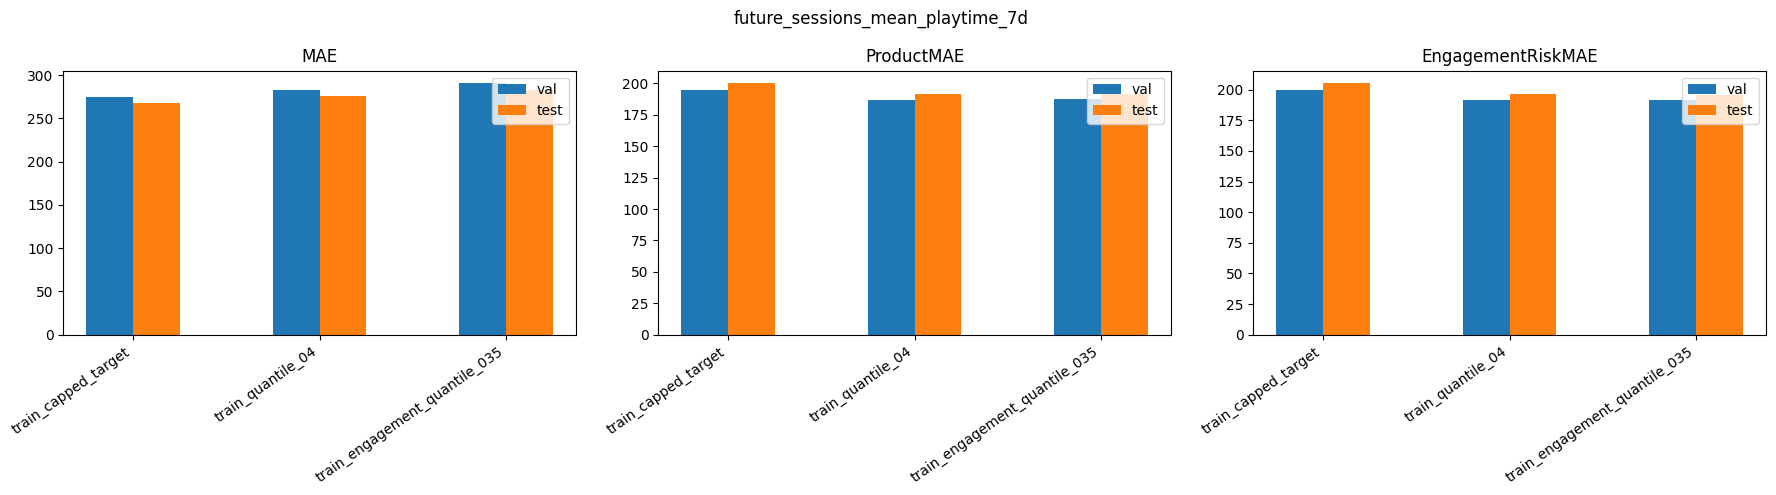

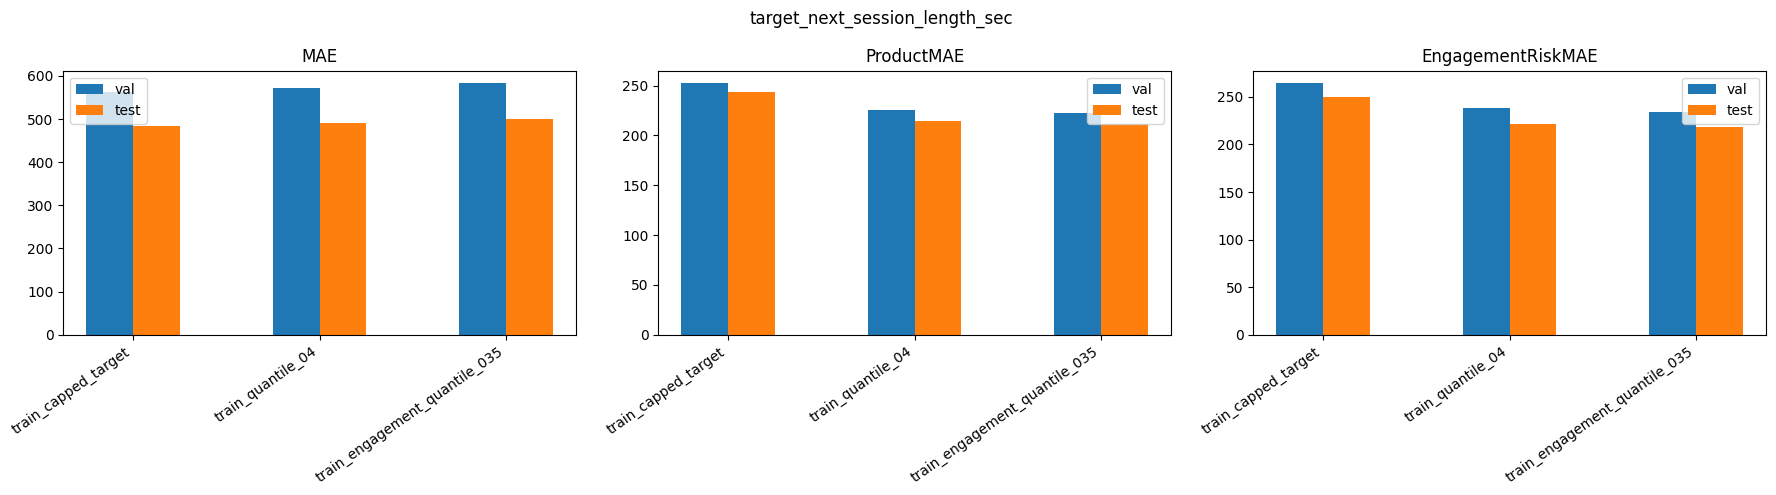

In [24]:
plot_df = res.groupby(['target', 'mode'], as_index=False).agg(
    val_mae=('val_mae', 'min'),
    test_mae=('test_mae', 'min'),
    val_product_mae=('val_product_mae', 'min'),
    test_product_mae=('test_product_mae', 'min'),
    val_engagement_risk_mae=('val_engagement_risk_mae', 'min'),
    test_engagement_risk_mae=('test_engagement_risk_mae', 'min'),
)

for t in plot_df['target'].unique():
    z = plot_df[plot_df['target'] == t].sort_values('test_mae').copy()
    x = np.arange(len(z))
    w = 0.25

    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    ax[0].bar(x - w / 2, z['val_mae'], width=w, label='val')
    ax[0].bar(x + w / 2, z['test_mae'], width=w, label='test')
    ax[0].set_title('MAE')

    ax[1].bar(x - w / 2, z['val_product_mae'], width=w, label='val')
    ax[1].bar(x + w / 2, z['test_product_mae'], width=w, label='test')
    ax[1].set_title('ProductMAE')

    ax[2].bar(x - w / 2, z['val_engagement_risk_mae'], width=w, label='val')
    ax[2].bar(x + w / 2, z['test_engagement_risk_mae'], width=w, label='test')
    ax[2].set_title('EngagementRiskMAE')

    for a in ax:
        a.set_xticks(x)
        a.set_xticklabels(z['mode'], rotation=35, ha='right')
        a.legend()

    fig.suptitle(t)
    plt.tight_layout()
    plt.show()

## LTV proxy слой для CRM

Доходного ground truth нет, поэтому строим только прокси для приоритизации пользователей.

In [ ]:
expected_ads_per_minute = 0.35
rpm_factor = 0.9

crm_pack = packs['future_sessions_mean_playtime_7d']
xte = crm_pack.x_test.copy()
yte = pd.Series(crm_pack.y_test, name='crm_true_sec').reset_index(drop=True)

best_by_product = res[res['target'] == 'future_sessions_mean_playtime_7d'].sort_values('test_product_mae').iloc[0]
chosen_mode = best_by_product['mode']
chosen_hp = {
    'depth': int(best_by_product['depth']),
    'learning_rate': float(best_by_product['lr']),
    'l2_leaf_reg': float(best_by_product['l2']),
}
mode_cfg = [m for m in mode_defs if m['mode'] == chosen_mode][0]

pred_tr, pred_va, pred_te = fit_predict_one_mode(crm_pack, mode_cfg, chosen_hp)
ltv_proxy_7d = (pred_te / 60.0) * expected_ads_per_minute * rpm_factor

rank_df = pd.DataFrame({
    'crm_pred_sec': pred_te,
    'crm_true_sec': yte.values,
    'ltv_proxy_7d': ltv_proxy_7d,
})
rank_df['priority_bucket'] = pd.qcut(rank_df['ltv_proxy_7d'].rank(method='first'), 5, labels=['low', 'mid_low', 'mid', 'mid_high', 'high'])
rank_df.groupby('priority_bucket', as_index=False).agg(
    users=('ltv_proxy_7d', 'size'),
    mean_proxy=('ltv_proxy_7d', 'mean'),
    mean_true_crm_sec=('crm_true_sec', 'mean'),
    mean_pred_crm_sec=('crm_pred_sec', 'mean'),
)

,priority_bucket,users,mean_proxy,mean_true_crm_sec,mean_pred_crm_sec
0,low,2100,0.639647,282.544103,121.837540
1,mid_low,2100,1.448179,407.243696,275.843672
2,mid,2100,1.958879,540.920710,373.119808
3,mid_high,2100,2.615853,687.627859,498.257724
4,high,2100,4.203437,974.369276,800.654582


In [25]:
alt = res[(res['target'] == 'future_sessions_mean_playtime_7d') & (res['mode'].isin(['train_quantile_04', 'train_capped_target', 'train_engagement_quantile_035']))]
alt = alt.sort_values('test_product_mae').groupby('mode', as_index=False).first()
alt[['mode', 'test_mae', 'test_product_mae', 'test_engagement_risk_mae', 'test_wmape', 'test_tail_weighted_mae_q90_w2']]


,mode,test_mae,test_product_mae,test_engagement_risk_mae,test_wmape,test_tail_weighted_mae_q90_w2
0,train_capped_target,268.056120,200.166342,205.633318,0.463331,326.467849
1,train_engagement_quantile_035,283.057266,191.781359,195.908527,0.489260,354.953106
2,train_quantile_04,276.723918,191.935552,196.306602,0.478313,345.283316


Вывод такой:

- Для CRM-приоритизации подход рабочий: бакеты от low до high реально разделяют пользователей по будущей вовлеченности
- Для минимальная ошибка в секундах берем train_capped_target
- Для цели - retention/engagement риск, берем train_engagement_quantile_035, потому что он лучше по продуктовым метрикам при допустимой потере MAE

## Формат CRM ответа для одного игрока

Ниже фиксируем единый формат ответа для CRM слоя.
Это не API реализация, а контракт структуры, который потом может использоваться в сервисе.

В этом блоке собираем json из предсказаний next session и weekly engagement, добавляем сегменты, флаги риска и рекомендуемый сценарий.


### Критерии


Критерии в этой логике такие.

Сегментация по длительности  
- small если значение до 300 секунд  
- normal если от 301 до 1200 секунд  
- long если больше 1200 секунд

next_session_segment считается по next_session.predicted_length_sec  
weekly_engagement_segment считается по weekly_engagement.predicted_mean_session_length_sec

crm_segment задается правилами  
- stable_normal для normal + normal  
- at_risk_short для small + small  
- high_engaged для long + long  
- recovering для small + normal или long  
- drop_risk для normal или long + small  
- mixed иначе

prediction_uncertainty считается из двух сигналов  
- churn_risk = churn_7d в диапазоне 0..1  
- activity_risk = 1 - clip(weekly_mean_7d / 1200, 0, 1)
(если w = 0 сек, риск = 1.0 (макс риск),
если w = 600 сек, риск = 0.5,
если w >= 1200 сек, риск = 0.0 (по этому сигналу риска почти нет).
То есть чем меньше ожидаемая недельная сессия, тем выше риск)

То есть чем меньше ожидаемая недельная активность, тем выше activity_risk

Итоговый риск  
- score = 0.6 * churn_risk + 0.4 * activity_risk  
- high если score >= 0.70  
- medium если score >= 0.45  
- low иначе

short_session_risk считается отдельно по next_session.cautious_length_sec  
- high если до 240 секунд  
- medium если 241–480 секунд  
- low если выше 480 секунд

avoid_early_ad становится true, если short_session_risk = high или prediction_uncertainty = high

recommended_scenario выбирается по приоритету  
- retention_offer если short_session_risk = high  
- light_touch если prediction_uncertainty = high  
- premium_offer если crm_segment = high_engaged  
- standard_offer в остальных случаях

model_metadata.generated_at это время формирования ответа в UTC  
model_metadata.model_version это версия модели

In [26]:
import json
from datetime import datetime, timezone

def seg(x):
    if x <= 300:
        return "small"
    if x <= 1200:
        return "normal"
    return "long"

def crm_seg(s1, s2):
    if s1 == "normal" and s2 == "normal":
        return "stable_normal"
    if s1 == "small" and s2 == "small":
        return "at_risk_short"
    if s1 == "long" and s2 == "long":
        return "high_engaged"
    if s1 == "small" and s2 in ("normal", "long"):
        return "recovering"
    if s1 in ("normal", "long") and s2 == "small":
        return "drop_risk"
    return "mixed"

def uncertainty_from_crm(churn_7d, weekly_mean_7d):
    c = float(np.clip(churn_7d, 0.0, 1.0))
    w = float(max(0.0, weekly_mean_7d))

    churn_risk = c
    activity_risk = 1.0 - np.clip(w / 1200.0, 0.0, 1.0)
    score = 0.6 * churn_risk + 0.4 * activity_risk

    if score >= 0.70:
        return "high"
    if score >= 0.45:
        return "medium"
    return "low"

def short_risk(cautious_len):
    if cautious_len <= 240:
        return "high"
    if cautious_len <= 480:
        return "medium"
    return "low"

def scenario(short_flag, unc_flag, crm_segment):
    if short_flag == "high":
        return "retention_offer"
    if unc_flag == "high":
        return "light_touch"
    if crm_segment in ("high_engaged",):
        return "premium_offer"
    return "standard_offer"

def build_crm_payload(player_id, next_session, weekly_engagement, model_version="crm_v1", generated_at=None):
    ns_seg = seg(next_session["predicted_length_sec"])
    wk_seg = seg(weekly_engagement["predicted_mean_session_length_sec"])
    cseg = crm_seg(ns_seg, wk_seg)

    churn_p = float(weekly_engagement.get("churn_7d", weekly_engagement.get("churn_probability_7d", 0.5)))
    weekly_mean = float(weekly_engagement["predicted_mean_session_length_sec"])

    u = uncertainty_from_crm(churn_p, weekly_mean)
    s = short_risk(next_session["cautious_length_sec"])
    avoid = (s == "high") or (u == "high")
    rec = scenario(s, u, cseg)

    if generated_at is None:
        generated_at = datetime.now(timezone.utc).replace(microsecond=0).isoformat().replace("+00:00", "Z")

    return {
        "player_id": str(player_id),
        "next_session": next_session,
        "weekly_engagement": weekly_engagement,
        "segments": {
            "next_session_segment": ns_seg,
            "weekly_engagement_segment": wk_seg,
            "crm_segment": cseg,
        },
        "risk_flags": {
            "short_session_risk": s,
            "prediction_uncertainty": u,
            "avoid_early_ad": bool(avoid),
        },
        "recommended_scenario": rec,
        "model_metadata": {
            "model_version": model_version,
            "generated_at": generated_at,
        },
    }


In [27]:
example = build_crm_payload(
    player_id="123",
    next_session={
        "predicted_length_sec": 420,
        "cautious_length_sec": 280,
        "interval_low_sec": 180,
        "interval_median_sec": 410,
        "interval_high_sec": 760,
    },
    weekly_engagement={
        "predicted_mean_session_length_sec": 680,
        "churn_7d": 0.72,
        "cautious_mean_session_length_sec": 510,
        "interval_low_sec": 350,
        "interval_median_sec": 670,
        "interval_high_sec": 980,
    },
    model_version="crm_v1",
    generated_at="2026-06-02T12:00:00Z",
)

print(json.dumps(example, ensure_ascii=False, indent=2))


{
  "player_id": "123",
  "next_session": {
    "predicted_length_sec": 420,
    "cautious_length_sec": 280,
    "interval_low_sec": 180,
    "interval_median_sec": 410,
    "interval_high_sec": 760
  },
  "weekly_engagement": {
    "predicted_mean_session_length_sec": 680,
    "churn_7d": 0.72,
    "cautious_mean_session_length_sec": 510,
    "interval_low_sec": 350,
    "interval_median_sec": 670,
    "interval_high_sec": 980
  },
  "segments": {
    "next_session_segment": "normal",
    "weekly_engagement_segment": "normal",
    "crm_segment": "stable_normal"
  },
  "risk_flags": {
    "short_session_risk": "medium",
    "prediction_uncertainty": "medium",
    "avoid_early_ad": false
  },
  "recommended_scenario": "standard_offer",
  "model_metadata": {
    "model_version": "crm_v1",
    "generated_at": "2026-06-02T12:00:00Z"
  }
}
